In [3]:
using PyPlot
using CSV
using DataFrames

plt.rcParams["font.sans-serif"] = "Helvetica";
plt.rcParams["font.family"] = "sans-serif";
plt.rcParams["font.size"] = 12;

using Pkg
Pkg.add("BioMart")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


# Analyse data on Hematopoiesis

## First dataset

In [4]:
# File paths
expr_file   = "/Users/ciarchi/Downloads/Haemopedia_expression.txt";
gene_file   = "/Users/ciarchi/Downloads/Haemopedia_probes.txt";
cell_file   = "/Users/ciarchi/Downloads/Haemopedia_samples.txt";

# Read tables
genes = CSV.read(gene_file, DataFrame; delim='\t', header=false);
cells = CSV.read(cell_file, DataFrame; delim='\t');
expr_wide = CSV.read(expr_file, DataFrame; delim='\t');

# Rename columns for matching while left-joining
rename!(expr_wide, names(expr_wide)[1] => :probe_id);
rename!(genes, names(genes)[1]=>:probe_id, names(genes)[2]=> :gene);
rename!(cells, names(cells)[1]=>:cell_id);

# Convert from wide to long format: cell ids become rows now
expr_long = stack(
    expr_wide,
    Not(:probe_id),
    variable_name = :cell_id,
    value_name = :expression
)

# Ensure cell IDs are strings
expr_long.cell_id = string.(expr_long.cell_id)

# Merge metadata

# Merge gene annotation
expr_annot = leftjoin(expr_long, genes, on = :probe_id)

# Merge cell annotation
expr_annot = leftjoin(expr_annot, cells, on = :cell_id)

#Print first five lines to check
first(expr_annot, 5)

Row,probe_id,cell_id,expression,gene,celltype,cell_lineage,tissue,description,surface_markers
,String15,String,Float64,String?,String15?,String31?,String31?,String?,String?
1,ILMN_2659724,iltp1786a-11,4.60852,ENSMUSG00000043398,B2,B Cell Lineage,Peritoneal,B2 B Cell,B220 Hi CD19+ F4/80-
2,ILMN_2713160,iltp1786a-11,4.58294,ENSMUSG00000000339,B2,B Cell Lineage,Peritoneal,B2 B Cell,B220 Hi CD19+ F4/80-
3,ILMN_1252621,iltp1786a-11,8.9148,ENSMUSG00000001518,B2,B Cell Lineage,Peritoneal,B2 B Cell,B220 Hi CD19+ F4/80-
4,ILMN_3162407,iltp1786a-11,12.0316,ENSMUSG00000044786,B2,B Cell Lineage,Peritoneal,B2 B Cell,B220 Hi CD19+ F4/80-
5,ILMN_2514723,iltp1786a-11,9.34914,ENSMUSG00000061461,B2,B Cell Lineage,Peritoneal,B2 B Cell,B220 Hi CD19+ F4/80-


In [5]:
# Select genes used in Omer's paper

using BioMart
import BioMart: Dataset, Filters, Attributes
using DataFrames

# Genes of interest
genes_of_interest = [
"Zfp385a","Tcf7","Bcl11a",
"Mxd1","Tbx21","Spi1",
"Klf4","Fosb","Mef2c",
"Spib","Pou2f2","Gata2",
"Rxra","Ikzf3","E2f2",
"Myb","Fos","Irf4",
"Bcl6","Hes1","Nr4a1",
"Satb1","Ikzf2","Atf3",
"Gfi1b","Creb3l1","Tal1",
"Fosl2","Gfi1","Irf5",
"Bhlhe40","Gata1","Ets1",
"Pou2af1","Ltf","Lyl1",
"Jdp2","Cebpa","Rara",
"Prdm1","Runx2","Hlx",
"Bach2","Erg","Meis3",
"Irf8","E2f8","Cxxc5",
"Zfpm1","Cebpe","Klf2",
"Maf","Cebpb","Nfil3",
"Nfe2","Zfp516","Hmgn3",
"Cebpd"
]


mapping = BioMart.query(
    Dataset("mmusculus_gene_ensembl"),
    Filters(external_gene_name = genes_of_interest),
    Attributes("external_gene_name", "ensembl_gene_id")
);

mapping = DataFrame(mapping);

rename!(mapping,
    "Gene name" => :gene_symbol,
    "Gene stable ID" => :gene
);

expr_filtered = innerjoin(
    expr_annot,
    mapping,
    on = :gene
);

In [4]:
# Select lineages choosen in Omer's paper

cell_types_of_interest = [
"B cell Lineage",
"Basophil Lineage",
"Dendritic cell Lineage",
"Eosinophil Lineage",
"Erythrocyte Lineage",
"Macrophage Lineage",
"Mast cell Lineage",
"Megakaryocyte Lineage",
"NK cell Lineage",
"Neutrophil Lineage",
"T cell Lineage"
]

expr_filtered_cells = filter(
    row -> row.cell_lineage in cell_types_of_interest,
    expr_filtered 
);

In [5]:
# Average over cell lineage every gene expression

using Statistics

expr_avg = combine(
    groupby(expr_filtered_cells, [:gene_symbol, :cell_lineage]),
    :expression => mean => :mean_expression
);

In [ ]:
# Crete matrix of gene expressions

expr_matrix_df = unstack(
    expr_avg,
    :gene_symbol,   # rows
    :cell_lineage,     # columns
    :mean_expression
);

gene_names = expr_matrix_df.gene_symbol;
lineage_names = names(expr_matrix_df[:,Not(:gene_symbol)]);

expr_matrix = Matrix(expr_matrix_df[:, Not(:gene_symbol)]);

## Second dataset

In [6]:
# Same for second dataset

# File paths
RAW_RNAseq_file   = "/Users/ciarchi/Downloads/Haemopedia-Mouse-RNASeq_raw.txt";
samples_file   = "/Users/ciarchi/Downloads/Haemopedia-Mouse-RNASeq_samples.txt";

#Read into DataFrames
RAW_RNAseq_df = CSV.read(RAW_RNAseq_file, DataFrame; delim='\t');
Sample_df = CSV.read(samples_file, DataFrame; delim='\t');

# Convert from wide to long format: cell ids become rows now
expr_long = stack(
    RAW_RNAseq_df,
    Not(:geneId),
    variable_name = :sampleId,
    value_name = :expression
)

# Ensure cell IDs are strings
expr_long.sampleId = string.(expr_long.sampleId);

# Merge cell annotation
expr_annot = leftjoin(expr_long, Sample_df, on = :sampleId);

In [7]:
# Select genes used in Omer's paper

using BioMart
import BioMart: Dataset, Filters, Attributes
using DataFrames

# Genes of interest
genes_of_interest = [
"Zfp385a","Tcf7","Bcl11a",
"Mxd1","Tbx21","Spi1",
"Klf4","Fosb","Mef2c",
"Spib","Pou2f2","Gata2",
"Rxra","Ikzf3","E2f2",
"Myb","Fos","Irf4",
"Bcl6","Hes1","Nr4a1",
"Satb1","Ikzf2","Atf3",
"Gfi1b","Creb3l1","Tal1",
"Fosl2","Gfi1","Irf5",
"Bhlhe40","Gata1","Ets1",
"Pou2af1","Ltf","Lyl1",
"Jdp2","Cebpa","Rara",
"Prdm1","Runx2","Hlx",
"Bach2","Erg","Meis3",
"Irf8","E2f8","Cxxc5",
"Zfpm1","Cebpe","Klf2",
"Maf","Cebpb","Nfil3",
"Nfe2","Zfp516","Hmgn3",
"Cebpd"
]


mapping = BioMart.query(
    Dataset("mmusculus_gene_ensembl"),
    Filters(external_gene_name = genes_of_interest),
    Attributes("external_gene_name", "ensembl_gene_id")
);

mapping = DataFrame(mapping);

rename!(mapping,
    "Gene name" => :gene_symbol,
    "Gene stable ID" => :geneId
);

expr_filtered = innerjoin(
    expr_annot,
    mapping,
    on = :geneId
);

In [8]:
# Select lineages choosen in Omer's paper

cell_lineages_of_interest = [
"B Cell Lineage",
"Basophil Lineage",
"Dendritic Cell Lineage",
"Eosinophil Lineage",
"Erythrocyte Lineage",
"Macrophage Lineage",
"Mast Cell Lineage",
"Megakaryocyte Lineage",
"NK Cell Lineage",
"Neutrophil Lineage",
"T Cell Lineage"
]

expr_filtered_lineages = filter(
    row -> row.cell_lineage in cell_lineages_of_interest,
    expr_filtered 
);

rename!(expr_filtered_lineages, "cell Type Description" => :cellTypeDescr);


In [9]:
# Remove progenitors

expr_filtered_lineages_no_prog = filter(
    row -> !(contains(row.cellTypeDescr, "Progenitor")),
    expr_filtered_lineages
);

In [10]:
#Filter by cells
cell_types_of_interest = [
"B Cell",
"Basophil",
"Dendritic Cell",
"Eosinophil",
"Erythrocyte",
"Macrophage",
"Mast Cell",
"Megakaryocyte",
"Mature Natural Killer Cell",
"Neutrophil",
"T Cell"
]

expr_filtered_cells = filter(
    row -> row.cellTypeDescr in cell_types_of_interest,
    expr_filtered_lineages 
);

In [ ]:
# Save filtered data frame

CSV.write("filtered_bygene_bylineage_RNAseq.csv", expr_filtered_lineages)

In [10]:
# Average over cell lineage every gene expression

using Statistics

expr_filtered_avg = combine(
    groupby(expr_filtered_lineages_no_prog, [:geneId, :cell_lineage]),
    :expression => mean => :mean_expression
);

In [11]:
# Crete matrix of gene expressions

expr_matrix_df = unstack(
    expr_filtered_avg,
    :geneId,   # rows
    :cell_lineage,     # columns
    :mean_expression
);

gene_names = expr_matrix_df.geneId;
lineage_names = names(expr_matrix_df[:,Not(:geneId)]);

expr_matrix = Matrix(expr_matrix_df[:, Not(:geneId)]);

#Transform matrix to log(1+x)
log_transf_expr_matrix = log10.(1.0.+expr_matrix);

#Normalize columns to one
for j in 1:size(log_transf_expr_matrix,2)
    log_transf_expr_matrix[:,j] ./= sqrt(sum(log_transf_expr_matrix[:,j].^2));
end

### Correlation matrix analysis

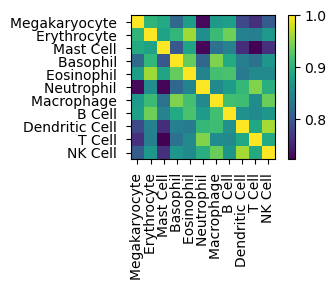

In [12]:
#Plot matrix of cosines between patterns

using Clustering
using Distances

# Create correlation matrix
corr_matrix = transpose(log_transf_expr_matrix)*log_transf_expr_matrix;

# Create distance matrix from correlation matrix
dist_matrix = pairwise(Euclidean(), 1 .- corr_matrix) 

# Cluster according to distance
hc = hclust(dist_matrix, linkage = :average)

# Get order of clustered rows
order = hc.order

# Reorder according to order from clustering
corr_ordered = corr_matrix[order, order]
lineage_ordered = lineage_names[order]


# Plot
fig = figure(figsize=(4,3));
imshow(corr_matrix, interpolation="nearest")
colorbar()

#Remove the "Lineage" from the lineages names
for i in eachindex(lineage_ordered)
    lineage_names[i] = replace(lineage_names[i], "Lineage" => "" );
    lineage_ordered[i]=replace(lineage_ordered[i], "Lineage" => "" );
end

xticks(0:length(lineage_ordered)-1, lineage_ordered, rotation=90)
yticks(0:length(lineage_ordered)-1, lineage_ordered)

tight_layout()
savefig("../Figures/Hematopoiesis_CorrelationMatrixCellTypes.pdf")
display(gcf())


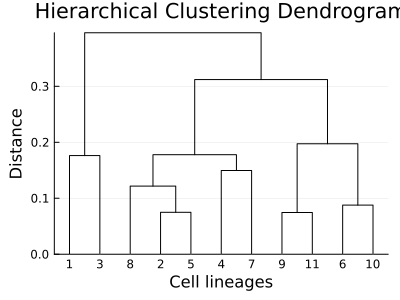

In [174]:
#Plot hierarchical tree

using StatsPlots

gr(size=(400,300));
StatsPlots.plot(hc,
     ylab   = "Distance",
     xlab = "Cell lineages",
     title  = "Hierarchical Clustering Dendrogram")

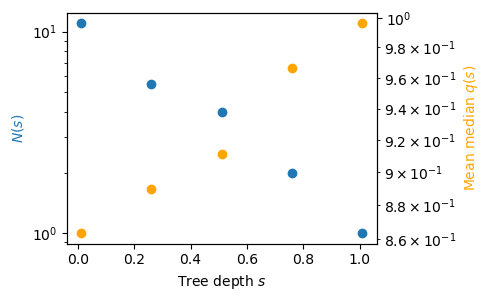

In [117]:
#Measure cluster size as a function of tree height 

using StatsBase #For countmap

n_cuts = 5 #Number of cuts to probe
heights = range(minimum(hc.heights), maximum(hc.heights), length = n_cuts); #Number of heights to probe

# For each cut height, get cluster assignments and record cluster sizes
cluster_sizes = map(heights) do h
    labels = cutree(hc; h = h)    ;      # assign each sample to a cluster
    counts = values(countmap(labels))   # size of each cluster
    (
        height     = h,
        n_clusters = length(counts),
        mean_size  = mean(counts),
        median_size= median(collect(counts)),
        max_size   = maximum(counts),
        min_size   = minimum(counts),
        sizes      = collect(counts),   # full distribution
    )
end

#Calculate overlap between sites of same cluster
cluster_overlaps = map(heights) do h
    labels = cutree(hc; h = h);
    cluster_ids = unique(labels);
    cluster_overlap = map(cluster_ids) do cid
        members = findall(labels .== cid)          # indices of sites in this cluster
        # Extract upper triangle of the submatrix (avoid duplicates and self-pairs)
        sub = corr_matrix[members, members]
        n = length(members)
        if n == 1
            diag_val = sub[1, 1]
            (
                cluster_id     = cid,
                size           = n,
                members        = members,
                overlaps       = [diag_val],
                mean_overlap   = diag_val,
                median_overlap = diag_val,
            )
        else
            pairs = [sub[i,j] for i in 1:n for j in i+1:n]
            (
                cluster_id     = cid,
                size           = n,
                members        = members,
                overlaps       = pairs,
                mean_overlap   = mean(pairs),
                median_overlap = median(pairs),
            )
        end
    end
    (
        height                = h,
        clusters              = cluster_overlap,
        median_median_overlap = median([c.median_overlap for c in cluster_overlap]),
        mean_mean_overlap = mean([c.mean_overlap for c in cluster_overlap]),
        mean_median_overlap = mean([c.median_overlap for c in cluster_overlap]),
        median_mean_overlap = median([c.mean_overlap for c in cluster_overlap])
    )
end


#Plot
heights    = [r.height      for r in cluster_sizes];
norm_heights = (heights.-heights[1])./(heights[end]-heights[1]).+0.01;
med_sizes  = [r.median_size for r in cluster_sizes];
med_overlap = [r.mean_mean_overlap for r in cluster_overlaps];


fig, ax1 = plt.subplots(figsize=(4,3))
ax1.scatter(norm_heights, reverse(med_sizes), color="C0")
# ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(L"Tree depth $s$")
ax1.set_ylabel(L"$N(s)$", color="C0")
ax2 = ax1.twinx()
ax2.scatter(norm_heights, reverse(med_overlap), color="orange")
ax2.set_ylabel(L"Mean median $q(s)$", color="orange")
ax2.set_yscale("log")

display(fig)

In [122]:
# Fit functional forms to cluster size N(s) and q(s)

using LsqFit

# Define model functions
Ns_law(s, p) = p[1] .* exp.(s .* p[2])
qs_law(s, p) = p[1] .* s .^ p[2] .+ p[3]

# Convert to plain arrays (LsqFit needs plain Vectors)
x = collect(norm_heights)
y_size    = collect(reverse(med_sizes))
y_overlap = collect(reverse(med_overlap))

# Initial parameter guesses [amplitude, exponent]
p0_Ns = [1.0, 1.0]
p0_qs = [1.0, 1.0, 1.0]

# Fit cluster size N(s)
fit_size = curve_fit(Ns_law, x, y_size, p0_Ns)
p_size   = coef(fit_size)
println("N(s) fit:  p1 = $(p_size[1]),  p2 = $(p_size[2])")
println("N(s) fit uncertainty: ", stderror(fit_size))

# Fit median overlap q(s)
fit_overlap = curve_fit(qs_law, x, y_overlap, p0_qs)
p_overlap   = coef(fit_overlap)
println("q(s) fit:  p1 = $(p_overlap[1]),  p2 = $(p_overlap[2]), p3 = $(p_overlap[3])")
println("q(s) fit uncertainty: ", stderror(fit_overlap))

N(s) fit:  p1 = 11.083725404474096,  p2 = -2.2907264163426384
N(s) fit uncertainty: [0.4900972837584569, 0.19270293757805668]
q(s) fit:  p1 = 0.1342781748558777,  p2 = 1.2847079284892102, p3 = 0.8632805518770977
q(s) fit uncertainty: [0.011486934866996385, 0.2583021978554483, 0.008983069694963843]


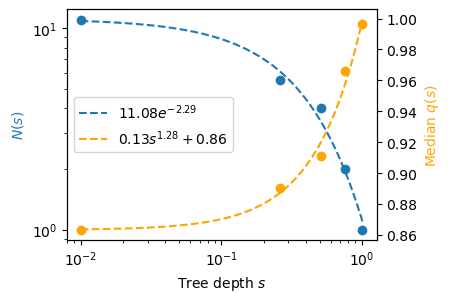

In [ ]:
# Plot fit on real curve
s_fit = 10 .^ range(log10(minimum(norm_heights)), log10(maximum(norm_heights)), length=200)

fig, ax1 = plt.subplots(figsize=(4, 3))

p1_size_lab = round(p_size[1], digits=2);
p2_size_lab = round(p_size[2], digits=2);

ax1.scatter(norm_heights, reverse(med_sizes), color="C0", zorder=3)
ax1.plot(s_fit, Ns_law(s_fit, p_size), color="C0", linestyle="--",
         label=L"%$(p1_size_lab)exp{%$(p2_size_lab)}")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(L"Tree depth $s$")
ax1.set_ylabel(L"$N(s)$", color="C0")


p1_overap_lab = round(p_overlap[1], digits=2);
p2_overap_lab = round(p_overlap[2], digits=2);
p3_overap_lab = round(p_overlap[3], digits=2);

ax2 = ax1.twinx()
ax2.scatter(norm_heights, reverse(med_overlap), color="orange", zorder=3)
ax2.plot(s_fit, qs_law(s_fit, p_overlap), color="orange", linestyle="--",
         label=L"%$(p1_overap_lab)s^{%$(p2_overap_lab)}+%$(p3_overap_lab)")
ax2.set_ylabel(L"Median $q(s)$", color="orange")
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(vcat(handles1, handles2), vcat(labels1, labels2), loc="center left")
display(fig)

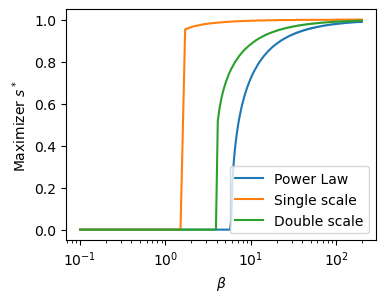

In [48]:
#Calculate maximum layer

using SpecialFunctions
using Optim
using PyPlot

f(x, b) = @. (0.863281 +0.134278*x^1.28471-(2.29*x)/b+0.172508*exp(2.29*x)*(-0.0486488+0.344919*gamma(1.28471,2.29*x)));

# Analytical expression taken from Mathematica Notebook ContinuumTransition.nb
fpl2(x, b)= @. 1/(2-x)^2.0-(1.0*x)/b+2.0*2.71828^(1.0*(-2.0+x))*((1.77072 -1.5708im)+((-2.0+x)^3.0*gamma(-2.0, (-2.0+1.0*x)))/(2.0 - x)^3); # exponent = 2.0
fpl0p5(x,b) = @. (-2.9253-1.77245im)*exp((-2.0+x))+exp((-1.0+x))+1/(2-x)^0.5-(x)/b+(-1.0+exp((-2.0+x))*sqrt(Complex(-2.0+x))*gamma(0.5,Complex(-2.0+x)))/sqrt(2.0 -x); # exponent = 0.5
fsinglescale(x,b) = @. 0.387242*exp(x)-1.08482*10^(-10)*exp(20.0*x)-x/b; # α = 1.0, γ = 20.0
fdoublescale(x,b) = @. 0.500411*exp(0.04*x)+0.360215*exp(x)-0.0676676*exp(2.0*x)-x/b; # α = 1.0, γ = 2.0

lower_bound = 0.0;
upper_bound = 1.0;
s_grid = range(lower_bound, upper_bound, length=1000);
b_values = range(0.1, 200.0, length=1000);
maximizers_pl = zeros(length(b_values));
maximizers_singlescale = zeros(length(b_values));
maximizers_doublescale = zeros(length(b_values));

for b in eachindex(b_values)
    beta = b_values[b];
    fs = real(fpl0p5(s_grid,beta));
    maximizers_pl[b] = findmax(fs)[2]*1/1000;
    fs = fsinglescale(s_grid,beta);
    maximizers_singlescale[b] = findmax(fs)[2]*1/1000;
    fs = fdoublescale(s_grid,beta);
    maximizers_doublescale[b] = findmax(fs)[2]*1/1000;
end

fig = figure(figsize=(4,3))
plot(b_values, maximizers_pl, label="Power Law")
plot(b_values, maximizers_singlescale, label="Single scale")
plot(b_values, maximizers_doublescale, label="Double scale")
xscale("log")
xlabel(L"$\beta$")
ylabel(L"Maximizer $s^*$")
legend(loc="lower right")
savefig("../Figures/LayerMaximiservsBeta_Continuum_ThreeExamples.pdf", bbox_inches="tight")

display(fig)

In [ ]:
#Find maximum correlation

function offdiag(ma)
  m, n = size(ma)
  M = similar(ma);
    for i in 1:m, j in 1:n
        if i == j
            M[i,j] = 0.0;
        else
            M[i,j] = ma[i,j];
        end
    end
    return M
end 

od = offdiag(corr_matrix);
odvec = vec(od);
pidx = sortperm(odvec, rev=true);
od_sorted = odvec[pidx];

cart_inds = [CartesianIndices(od)[i] for i in pidx][1:(end-11)]

# Analyze dynamics of patterns from RNA-seq data

In [19]:
#Introduce necessary libraries
using ProgressLogging
using TerminalLoggers
using Random
using LinearAlgebra
using UMAP

## Define necessary functions for simulation of dynamics and analysis

In [20]:
#Dynamics with random connectivity matrix
function enhancenet_dyn_ss(conn_mat_::Matrix{Float64}, T_::Float64, dt_::Float64, beta_::Float64,
                            N_genes_::Int64, N_enhancers_::Int64, N_states_::Int64,
                            noise_int_::Float64)
    #Define state vectors
    sstates::Matrix{Float64} = zeros(N_states, N_genes);
    #Random initial condition
    x::Vector{Float64} = randn(N_genes_);
    #Transpose matrix
    intermediate::Vector{Float64} = zeros(N_genes_); #Intermediate vector for calculations
    #Run Dynamics
    Nt::Int64 = floor(T_/dt_);
    norm::Float64 = 0.0; #Softmax normalizaton
    soft_max_v::Vector{Float64} = zeros(N_enhancers_); #Softmax vector

    for s in 1:N_states_
        #Random initial condition
        randn!(x)
        
        #Dynamics
        for t in 1:Nt
            mul!(soft_max_v, conn_mat_, x);   # soft_max_v = conn_mat_ * x
            for j in 1:N_enhancers_
                soft_max_v[j] = exp(beta_ * soft_max_v[j]);
            end
            tot_sum = sum(soft_max_v);
            for j in 1:N_enhancers_
                soft_max_v[j] = soft_max_v[j]/tot_sum;
            end
            mul!(intermediate, transpose(conn_mat_), soft_max_v)
            for i in eachindex(x)
                x[i] += dt_ * (intermediate[i] - x[i])+sqrt(2*dt_*noise_int_)*randn();
                if isnan(x[i])
                    error("NaN encountered during dynamics. Aborting.")
                end
            end
        end
        for i in eachindex(x)
            sstates[s,i] = x[i];
        end
        
    end
    return sstates

end

#Dynamics with random connectivity matrix for overlap
function enhancenet_dyn_rand(T_::Float64, dt_::Float64, beta_::Float64, N_genes_::Int64, N_enhancers_::Int64)
    #Generate random matrix of connections by drawing random vector on the sphere
    conn_mat::Matrix{Float64} = randn(N_enhancers_, N_genes_)/sqrt(N_genes_);
    # for row in 1:N_enhancers_
    #     conn_mat[row,:] = @view(conn_mat[row,:])/sqrt(sum(@view(conn_mat[row,:]).^2));
    # end
    #Transpose matrix
    conn_mat_t = transpose(conn_mat);
    #Random initial condition
    x::Vector{Float64} = randn(N_genes_);
    intermediate::Vector{Float64} = zeros(N_genes_); #Intermediate vector for calculations
    #Run Dynamics
    Nt::Int64 = floor(T_/dt_);
    norm::Float64 = 0.0; #Softmax normalizaton
    soft_max_v::Vector{Float64} = zeros(N_enhancers_); #Softmax vector
    for t in 1:Nt
        soft_max_v .= exp.(beta_.*conn_mat*x);
        norm = sum(soft_max_v);
        soft_max_v .= soft_max_v./norm;
        intermediate .= conn_mat_t*soft_max_v;
        for i in eachindex(x)
            x[i] = x[i] + dt_*(intermediate[i]-x[i])+sqrt(2*dt_/beta_)*randn();
        end
    end
    return conn_mat, x

end

#Overlap calculations
function calc_overlaps!(overlaps_::Vector{Float64}, patterns_prod_::Vector{Float64}, T_::Float64, dt_::Float64, beta_::Float64, N_genes_::Int64, N_enhancers_::Int64, N_replicas_::Int64, sstates_::Matrix{Float64})
    #Define matrices of patterns
    conn_mat::Matrix{Float64} = zeros(N_enhancers_,N_genes_);
    #Get steady states for every replica
    @progress for r in 1:N_replicas_
        conn_mat, sstates_[:,r] = enhancenet_dyn_rand(T_, dt_, beta_, N_genes_, N_enhancers_);
        for j in 1:N_enhancers_
            patterns_prod_[j+(r-1)*(N_enhancers_)] = sum(@view(sstates_[:,r]).*@view(conn_mat[j,:]));
        end
    end
    #Calculate overlap matrix
    for r in 1:N_replicas_
        overlaps_[((r-1)*N_replicas_+1):(r*N_replicas_)] .= transpose(sstates_)*@view(sstates_[:,r])/N_genes_;
    end
end

#Annealing (beta) simulation
function enhancenet_dyn_ann(patterns_::Matrix{Float64}, conn_mat_::Matrix{Float64},
                            Nt_::Int64, dt_::Float64, tsave_tot_::Int64, t_skip_::Int64,
                            beta_max_::Float64, beta_steps_::Int64,
                            N_genes_::Int64, N_enhancers_::Int64, N_states_::Int64,
                            noise_int_::Float64)
    
    #Random initial condition
    x::Vector{Float64} = randn(N_genes_);
    #Initial beta value
    beta::Float64 = 0.0;
    #Transpose matrix
    # conn_mat_t = transpose(conn_mat_);
    intermediate::Vector{Float64} = zeros(N_genes_); #Intermediate vector for calculations
    
    #Calculate time at which to anneal beta
    dbeta::Float64 = beta_max_/beta_steps_;
    t_beta_ann::Int64 = Int(Nt_/beta_steps_);

    println("Beta update every $t_beta_ann steps")

    #Total saved time points and counter
    tsave::Int64 = Int(Nt_/tsave_tot_);
    current_tsave::Int64 = 1;

    println("Save state every $tsave steps")

    #Run Dynamics
    norm::Float64 = 0.0; #Softmax normalizaton
    soft_max_v::Vector{Float64} = zeros(N_enhancers_); #Softmax vector

    @progress for s in 1:N_states_
        
        #Random initial condition
        for i in eachindex(x)
            x[i] = randn();
        end

        #Reset beta
        beta = 0.0;
        
        #Dynamics
        for t in 1:Nt_
            if t % t_beta_ann == 0
                beta += dbeta;
                println("Beta updated to $(beta).")
            end
            if t % tsave == 0
                if current_tsave > t_skip_
                    for i in eachindex(x)
                        patterns_[i,(s-1)*(tsave_tot_-t_skip_)+(current_tsave-t_skip_)] = x[i];
                    end
                end
                current_tsave += 1 ;
            end
            for j in 1:N_enhancers_
                enhancer_activity::Float64 = 0.0;
                for i in 1:N_genes_
                    enhancer_activity += beta * conn_mat_[j,i]*x[i];
                end
                soft_max_v[j] = exp(enhancer_activity);
            end
            tot_sum::Float64 = 0.0;
            for j in 1:N_enhancers_
                tot_sum += soft_max_v[j];
            end
            for i in 1:N_genes_
                intermediate[i] = 0.0;
                for j in 1:N_enhancers_
                    intermediate[i] += conn_mat_[j,i]*soft_max_v[j]/tot_sum;
                end
            end
            for i in eachindex(x)
                x[i] = x[i] + dt_*(intermediate[i]-x[i])+sqrt(2*dt_*noise_int_)*randn();
                if isnan(x[i])
                    error("NaN encountered during dynamics. Aborting.")
                end
            end
        end
        current_tsave = 1;
    end

end

#Function to get conjugate variables wk
function get_wk(xs::Vector{Float64}, P::Matrix{Float64}, beta::Float64)
    
    y_k::Vector{Float64} = beta .* P*xs;
    return exp.(y_k)/sum(exp.(y_k));

end


get_wk (generic function with 1 method)

## Simulate dynamics and obtain steady-state information

In [87]:
#Study steady state for single connectivity matrix

#Define variables
T::Float64 = 100.0; #Total time
dt::Float64 = 0.01; 
N_genes::Int64 = size(log_transf_expr_matrix, 1); #Number of genes from log count matrix
N_enhancers::Int64 = size(log_transf_expr_matrix, 2); #Number of enhancers from log count matrix
N_states::Int64 = 100;

#Generate connectivity matrix
conn_mat::Matrix{Float64} = transpose(log_transf_expr_matrix); #Need to transpode log count matrix
#Create vectors of betas
betas::Vector{Float64} = [20.0, 33.55, 33.8, 40, 50, 59.5, 200.0];
states::Array{Float64,3} = zeros(length(betas),N_states,N_genes);
#Noise intensity
noise_int::Float64 = 0.00;

#Get steady states for values of beta
Threads.@threads for b in eachindex(betas)
    println("Calculating stedy states for β=$(betas[b]).")
    states[b,:,:] = enhancenet_dyn_ss(conn_mat, T, dt, betas[b], N_genes, N_enhancers, N_states, noise_int);
end


Calculating stedy states for β=200.0.
Calculating stedy states for β=20.0.
Calculating stedy states for β=50.0.
Calculating stedy states for β=33.8.
Calculating stedy states for β=33.55.
Calculating stedy states for β=59.5.
Calculating stedy states for β=40.0.


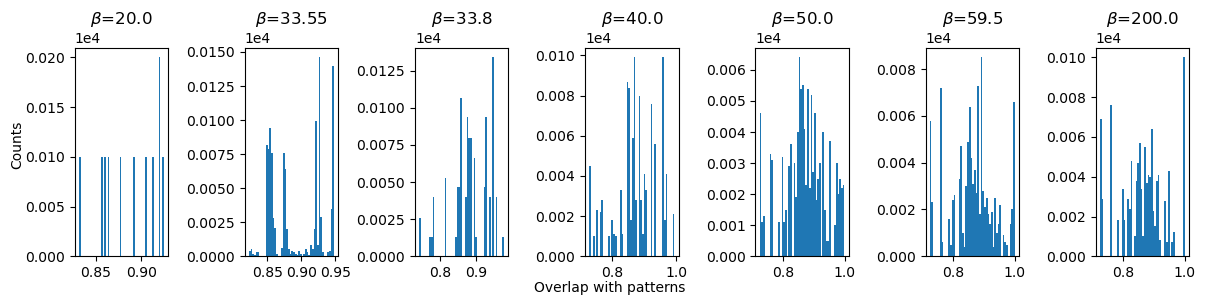

In [88]:
#Overlaps with patterns
patterns::Matrix{Float64} = zeros(length(betas), N_states*N_enhancers);

for b in eachindex(betas)
    for r in 1:N_states
        for j in 1:N_enhancers
            patterns[b,j+(r-1)*(N_enhancers)] = sum(@view(states[b,r,:]).*@view(conn_mat[j,:]));
        end
    end
end

#Plot
fig, axs = subplots(1,length(betas),figsize=(12,3))
for b in eachindex(betas)
    axs[b].hist(@view(patterns[b,:]),bins=50);
    # axs[b].set_xlim(0.0,1.0);
    # axs[b].set_ylim(0,N_states*N_enhancers/2)
    axs[b].ticklabel_format(axis="y", style="sci", scilimits=(4,4))
    axs[b].set_title(L"$\beta$="*"$(betas[b])")
end
fig.text(0.5, 0.01, "Overlap with patterns", ha="center")
fig.text(0.00, 0.5, "Counts", va="center", rotation="vertical")
tight_layout();
display(gcf())

In [ ]:
#Calculate wk
wks::Matrix{Float64} = zeros(length(betas), N_states*N_enhancers);

for b in eachindex(betas)
    for r in 1:N_states
        w_k = get_wk(states[b,r,:], conn_mat, betas[b]);
        for j in 1:N_enhancers
            wks[b,j+(r-1)*(N_enhancers)] = w_k[j];
        end
    end
end

#Plot
fig, axs = subplots(1,length(betas),figsize=(12,3))
for b in eachindex(betas)
    axs[b].hist(@view(wks[b,:]),bins=50);
    # axs[b].set_xlim(0.0,1.0);
    # axs[b].set_ylim(0,N_states*N_enhancers/2)
    axs[b].ticklabel_format(axis="y", style="sci", scilimits=(4,4))
    axs[b].set_title(L"$\beta$="*"$(betas[b])")
end
fig.text(0.5, 0.01, "w_k", ha="center")
fig.text(0.00, 0.5, "Counts", va="center", rotation="vertical")
tight_layout();
display(gcf())

In [89]:
#UMAP of selected steady states
umap_plots = []
for b in eachindex(betas)
    println("Doing umap for beta=$(betas[b]).")
    push!(umap_plots,UMAP.fit((transpose(states[b,:,:])), 2 ; n_neighbors=30, min_dist = 0.1));
end

Doing umap for beta=20.0.
Doing umap for beta=33.55.
Doing umap for beta=33.8.
Doing umap for beta=40.0.
Doing umap for beta=50.0.
Doing umap for beta=59.5.
Doing umap for beta=200.0.


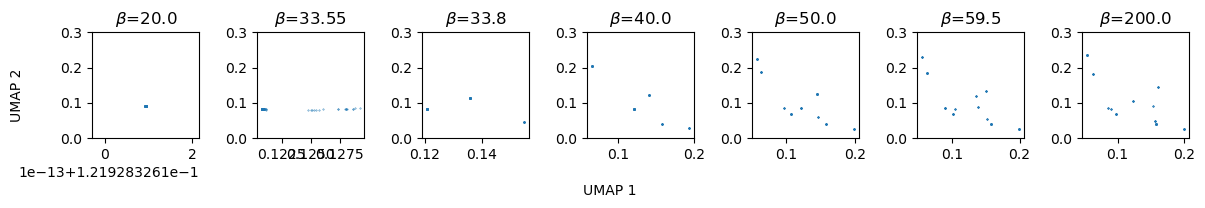

In [90]:
#Plot UMAPs

#Plot
fig, axs = subplots(1,length(betas),figsize=(12,2))
for b in eachindex(betas)
    axs[b].scatter((umap_plots[b].data[1,:]),(umap_plots[b].data[2,:]),s = 0.1);
    axs[b].set_title(L"$\beta$="*"$(betas[b])")
    axs[b].set_ylim(0.00,0.3);
    # axs[b].set_xlim(0.1,0.15);
end
tight_layout();
fig.text(0.5, 0.00, "UMAP 1", ha="center")
fig.text(0.00, 0.5, "UMAP 2", va="center", rotation="vertical")
display(gcf())

### Spectrum of matrix

In [ ]:
Graham_matrix = conn_mat*conn_mat';

b_sel = 4;
beta_sel = betas[b_sel];
state_sel = 2;
w_k = get_wk(states[b_sel,state_sel,:], conn_mat, betas[b_sel]);


println(w_k, "\n", argmax(w_k))

J = beta_sel .* (Diagonal(w_k)-w_k*w_k') * Graham_matrix;

Spectrum = eigen(J)

In [ ]:
#Get indices of maxima and plot histogram
b_sel = 3;
idx_maxima = zeros(N_states);
for i in 1:N_states
    w_k = get_wk(states[b_sel,i,:], conn_mat, betas[b_sel]);
    idx_maxima[i] = argmax(w_k);
end

fig = figure(figsize=(4,3));
plt.hist(idx_maxima)
plt.xticks(ticks=1:11, labels = ["$i" for i in 1:11])
display(gcf())
println(unique(idx_maxima))

In [ ]:
#Calculate wk
sel_wk = 1:11;
n_wks = length(sel_wk);
sel_betas = [6,7];
n_betas = length(sel_betas);
wks_sel::Array{Float64} = zeros(n_wks, N_states);


for r in 1:N_states
    w_k1 = get_wk(states[sel_betas[1],r,:], conn_mat, betas[sel_betas[1]]);
    w_k2 = get_wk(states[sel_betas[2],r,:], conn_mat, betas[sel_betas[2]]);

    dwk = w_k2 .- w_k1;

    for i in eachindex(sel_wk)
        wks_sel[i,r] = dwk[sel_wk[i]];
    end    
end


#Plot
fig, axs = subplots(n_wks, 1, figsize=(3,12))
for w in eachindex(sel_wk)
    axs[w,1].hist(@view(wks_sel[w,:]),bins=50);
    axs[w,1].ticklabel_format(axis="y", style="sci", scilimits=(4,4))
    # axs[w,1].set_title(L"$\beta$="*"$(betas[sel_betas[1]])")
end

fig.text(0.5, 0.01, "w_k", ha="center")
fig.text(0.00, 0.5, "Counts", va="center", rotation="vertical")
tight_layout();
display(gcf())

## Beta annealing analysis

In [ ]:
#Beta Annealing dynamics

#Define variables and containers
T::Float64 = 200.0; #Total time
dt::Float64 = 0.01;
Nt::Int64 = Int(T/dt);
t_skip::Int64 = 10; #Initial transient to skip
tsave_tot::Int64 = 200;
beta_max::Float64 = 80.0;
beta_steps::Int64 = 100;
N_replicas::Int64 = 100;
patterns_ann::Matrix{Float64} = zeros(N_genes, (tsave_tot-t_skip)*N_replicas);
noise_int::Float64 = 0.0001;

#Run annealing dynamics
enhancenet_dyn_ann(patterns_ann, conn_mat,
                    Nt, dt, tsave_tot, t_skip,
                    beta_max, beta_steps,
                    N_genes, N_enhancers, N_replicas, noise_int);

In [ ]:
#Calculate overlap with patterns
#Overlaps with patterns


patterns_overlaps_ann::Vector{Float64} = zeros((tsave_tot-t_skip)*N_replicas);
patterns_overlap_single::Vector{Float64} = zeros(N_enhancers);

for r in 1:(N_replicas*(tsave_tot-t_skip))
    for j in 1:N_enhancers
        patterns_overlap_single[j] = sum(@view(patterns_ann[:,r]).*@view(conn_mat[j,:]));
    end
    patterns_overlaps_ann[r] = maximum(patterns_overlap_single);
end

In [ ]:
#Plot histogram of patternsf
fig = figure();
hist(patterns_overlaps_ann,bins=50)
xlim(0,1.2)
display(gcf())

In [ ]:
#Crete UMAP
umap_dyn = UMAP.fit(patterns_ann, 2; n_neighbors=30, min_dist = 0.01);

In [ ]:
#Plot UMAP
fig = figure(figsize=(4,3))
scatter(umap_dyn.data[1,:],umap_dyn.data[2,:],c=(patterns_overlaps_ann),vmin=0.9, vmax=1.0)
colorbar(label="Maximum overlap with patterns")
xlabel("UMAP 1")
ylabel("UMAP 2")
display(gcf())

## Entropy calculation

In [ ]:
#Define function to calculate entropy

function get_entropy(states::Matrix{Float64}, beta::Float64, conn_mat::Matrix{Float64},
                     N_states::Int64, N_enhancers::Int64)

    entropy::Float64 = 0.0;
    wk::Vector{Float64} = zeros(N_enhancers);
    for n in 1:N_states
        wk = get_wk(states[n,:], conn_mat, beta);
        for i in 1:N_enhancers
            entropy += 1/N_states*(wk[i]*log(wk[i]));
        end
    end

    return entropy

end

In [ ]:
#Calculate entropy of steady states in simplex space for different values of beta

#Define variables
T::Float64 = 100.0; #Total time
dt::Float64 = 0.01; 
N_genes::Int64 = size(log_transf_expr_matrix, 1); #Number of genes from log count matrix
N_enhancers::Int64 = size(log_transf_expr_matrix, 2); #Number of enhancers from log count matrix
N_states::Int64 = 1000; #Number of sampled states

#Generate connectivity matrix
conn_mat::Matrix{Float64} = transpose(log_transf_expr_matrix); #Need to transpode log count matrix
#Create vectors of betas
betas::Vector{Float64} = 1:1:200;
#Create vector of entropies
entropies::Vector{Float64} = similar(betas);
#Create array of states (allegedly thread safe)
n_threads = Threads.nthreads();
states_bb::Array{Float64,3} = zeros(n_threads, N_states, N_genes);
#Noise intensity
noise_int::Float64 = 0.00;

#Get steady states for values of beta
Threads.@threads for b in eachindex(betas)
    thread_id = Threads.threadid();
    println("Calculating stedy states for β=$(betas[b]) in thread $thread_id.")
    β::Float64 = betas[b];
    states_bb[thread_id-1, :, :] .= enhancenet_dyn_ss(conn_mat, T, dt, betas[b], N_genes, N_enhancers, N_states, noise_int);
    entropies[b] = get_entropy(states_bb[thread_id-1, :, :], β, conn_mat, N_states, N_enhancers);
end


In [82]:
#Find transitions numerically via derivatives
using Interpolations, Peaks, DSP

# Assuming you have beta (log-spaced) and y vectors
# Fit a smooth interpolant first
itp = cubic_spline_interpolation(1:1:200, entropies)  # or use Interpolations.jl

fine_grid = 1:1:200
dy_fine   = [Interpolations.gradient(itp, b)[1] for b in fine_grid]
d2y_fine  = [Interpolations.hessian(itp, b)[1,1] for b in fine_grid]

smoothing = 10;
dy_smooth = conv(dy, ones(smoothing)/smoothing)[smoothing÷2:end-smoothing÷2]  # simple moving average
peak_indices = argmaxima(dy_smooth,3)
beta_transitions = betas[round.(Int, fine_grid[peak_indices])]

BoundsError: BoundsError: attempt to access 7-element Vector{Float64} at index [[38, 91, 112, 125, 134, 141, 148, 157]]

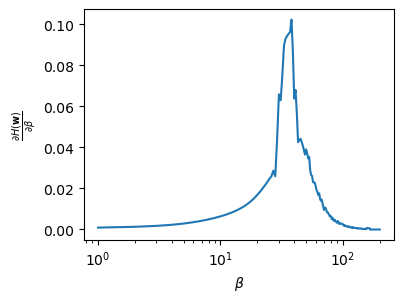

In [66]:
fig = figure(figsize=(4,3))
plot(betas,dy_smooth)
xlabel(L"$\beta$")
ylabel(L"$\frac{\partial H(\mathbf{w})}{\partial\beta}$")
plt.xscale("log")
display(gcf())

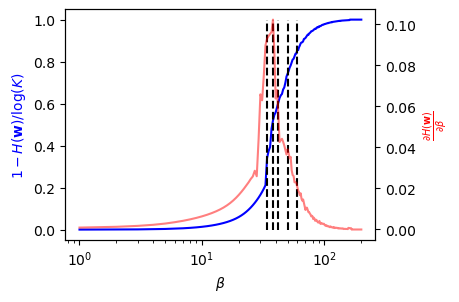

In [124]:
#Plot
fig, ax1 = plt.subplots(figsize=(4,3))
ax1.plot(betas,1.0.+entropies/log(N_enhancers),color="blue")
ax1.vlines(x=[34, 38, 42, 50, 60],ymin=0, ymax=1,color="black",linestyle="dashed")
ax1.set_xlabel(L"$\beta$")
ax1.set_ylabel(L"$1-H(\mathbf{w})/\log(K)$",color="blue")
ax1.set_xscale("log")
ax2 = ax1.twinx()
ax2.plot(betas,dy_smooth,color="red",alpha=0.5)
ax2.set_ylabel(L"$\frac{\partial H(\mathbf{w})}{\partial\beta}$",color="red")
display(gcf())



### Select unique fixed point and plot values of components on patterns

In [113]:
#Define variables
T::Float64 = 100.0; #Total time
dt::Float64 = 0.01; 
N_genes::Int64 = size(log_transf_expr_matrix, 1); #Number of genes from log count matrix
N_enhancers::Int64 = size(log_transf_expr_matrix, 2); #Number of enhancers from log count matrix
N_states::Int64 = 1000; #Number of sampled states
n_threads = Threads.nthreads(); #Number of threads

#Generate connectivity matrix
conn_mat::Matrix{Float64} = transpose(log_transf_expr_matrix); #Need to transpode log count matrix

function is_unique(fp::Vector{Float64}, unique_fps::Vector{Any}; tol=1e-3)
    return all([norm((fp) .- (ufp)) > tol for ufp in unique_fps])
end

betas_fpoints = [20, 34, 38, 45, 50, 60]
states_fpoints::Array{Float64,3} = zeros(n_threads, N_states, N_genes);
wks = [[] for b in betas_fpoints];

#Get steady states for values of beta
Threads.@threads for b in eachindex(betas_fpoints)
    thread_id = Threads.threadid();
    beta::Float64 = betas_fpoints[b];
    println("Calculating stedy states for β=$(beta) in thread $thread_id.")
    states_fpoints[thread_id-1, :, :] .= enhancenet_dyn_ss(conn_mat, T, dt, beta, N_genes, N_enhancers, N_states, 0.0);
    #Get unique fixed points
    fps = states_fpoints[thread_id-1, :, :];
    unique_wks::Vector{Vector{Float64}} = [];
    wk::Vector{Float64} = zeros(N_enhancers);
    wk = get_wk(fps[1,:],conn_mat, beta);
    push!(unique_wks, wk)
    for i in 2:N_states
        wk = get_wk(fps[i,:],conn_mat, beta);
        if all([norm((wk) .- (ufp)) > 1e-3 for ufp in unique_wks])
            push!(unique_wks, wk)
        end
    end
    println("Found $(length(unique_wks)) unique fixed points at β=$beta.")
    push!(wks[b], unique_wks);
end

Calculating stedy states for β=50.0 in thread 3.
Calculating stedy states for β=60.0 in thread 2.
Calculating stedy states for β=38.0 in thread 5.
Calculating stedy states for β=20.0 in thread 4.
Found 5 unique fixed points at β=38.0.
Calculating stedy states for β=45.0 in thread 5.
Found 1 unique fixed points at β=20.0.
Calculating stedy states for β=34.0 in thread 4.
Found 11 unique fixed points at β=60.0.
Found 9 unique fixed points at β=50.0.
Found 7 unique fixed points at β=45.0.
Found 3 unique fixed points at β=34.0.


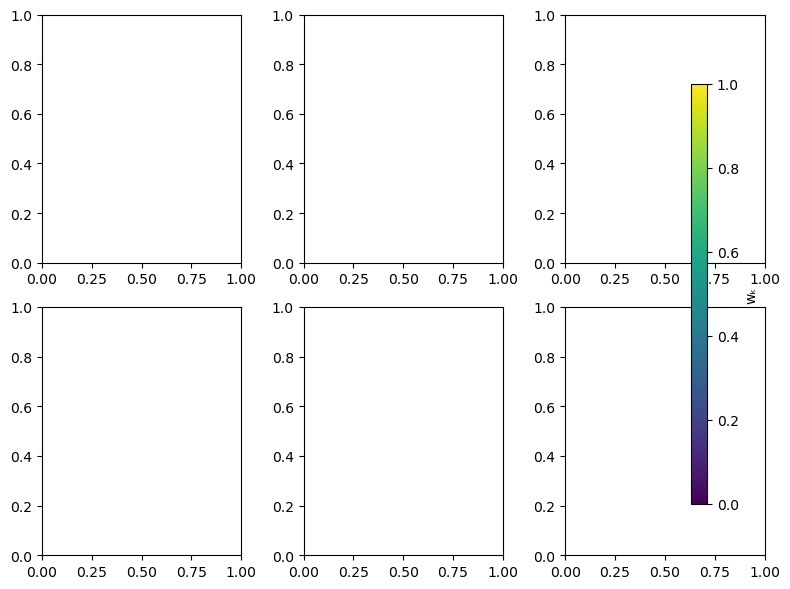

<sys>:0: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


In [208]:
#Plot


n_betas = length(betas_fpoints)
fig, axes = subplots(2, 3, figsize=(8, 6))  # 2 rows, 3 cols

last_im = nothing; #Last image for colorbar

for (b, beta) in enumerate(betas_fpoints)
    
    fps = wks[b][1]
    n_fps = length(fps)

    # Stack into matrix, sort each fp descending
    W = hcat([fp for fp in fps]...)'  # n_unique × N_enhancers
    W_ordered_cols = W[:, order] # Order from correlation matrix
    
    # For each cell type (column), find which FP has the highest value there
    row_order = [argmax(W_ordered_cols[:, j]) for j in 1:size(W_ordered_cols, 2)]

    # row_order may have duplicates if some FPs dominate multiple genes
    # deduplicate while preserving order
    seen = Set{Int}()
    row_order_unique = [x for x in row_order if x ∉ seen && push!(seen, x) == seen]
    # append any remaining FPs not yet included
    remaining = [i for i in 1:size(W_ordered_cols, 1) if i ∉ seen]
    row_order_final = vcat(row_order_unique, remaining)

    W_final = W_ordered_cols[row_order_final, :]

    # Convert 2D PyObject index to row, col
    row = (b - 1) ÷ 3+1
    col = (b - 1) % 3+1
    ax = axes[row, col]  # 0-indexed row/col for PyPlot
    # last_im = ax.imshow(W_final, aspect="auto", vmin=0, vmax=1, cmap="viridis",
                        # interpolation="nearest")
    # ax.set_title("β = $(round(beta, digits=2))")
    # ax.set_xlabel("Cell type")
    
    # Y axis: one tick per fixed point
    # ax.set_yticks(0:n_fps-1)
    # ax.set_yticklabels(["FP $i" for i in 1:n_fps])
    
    # # X axis: custom gene name labels
    # ax.set_xticks(0:length(lineage_ordered)-1)
    # ax.set_xticklabels(lineage_ordered, rotation=45, ha="right", fontsize=8)
    # if b == 1 || b == 4
    #     ax.set_ylabel("Fixed point #")
    # end
end

# Shared colorbar
# fig.subplots_adjust(right=0.85, hspace=0.6, wspace=0.4)
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
fig.colorbar(last_im, cax=cbar_ax, label="wₖ")

tight_layout()
display(fig)
savefig("../Figures/Hematopoiesis_HeatMapsFixedPoints_VaryingBeta.pdf")